<a href="https://colab.research.google.com/github/GandharvaThite/ADM-Project/blob/main/Approach_3_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In the Approach-3 we will be applying XAI techniques and further tabulating the values of XAI metrics applied on the XAI techniques for all the models used in Approach-1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import zscore
from sklearn.model_selection import KFold
from xgboost import XGBRFClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold,StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import tensorflow as tf
from tqdm import tqdm
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from scipy.stats import pearsonr
import warnings
import joblib

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/cicids2017_curated_38cols_Binary_Latest.csv")

In [ ]:
X = df.drop(columns=['Label'])
Y = df['Label']
scaler = StandardScaler()

In [ ]:
warnings.filterwarnings("ignore")
model = joblib.load("/content/Logistic.pkl")

In [ ]:
features = []
for i in range(0,X.shape[1]):
  features.append(i)

In [ ]:
X_pdp, _, y_pdp, _ = train_test_split(X,Y,train_size=100000,stratify=Y,random_state=0)


Generating PDPs: 100%|██████████| 37/37 [02:30<00:00,  4.06s/it]


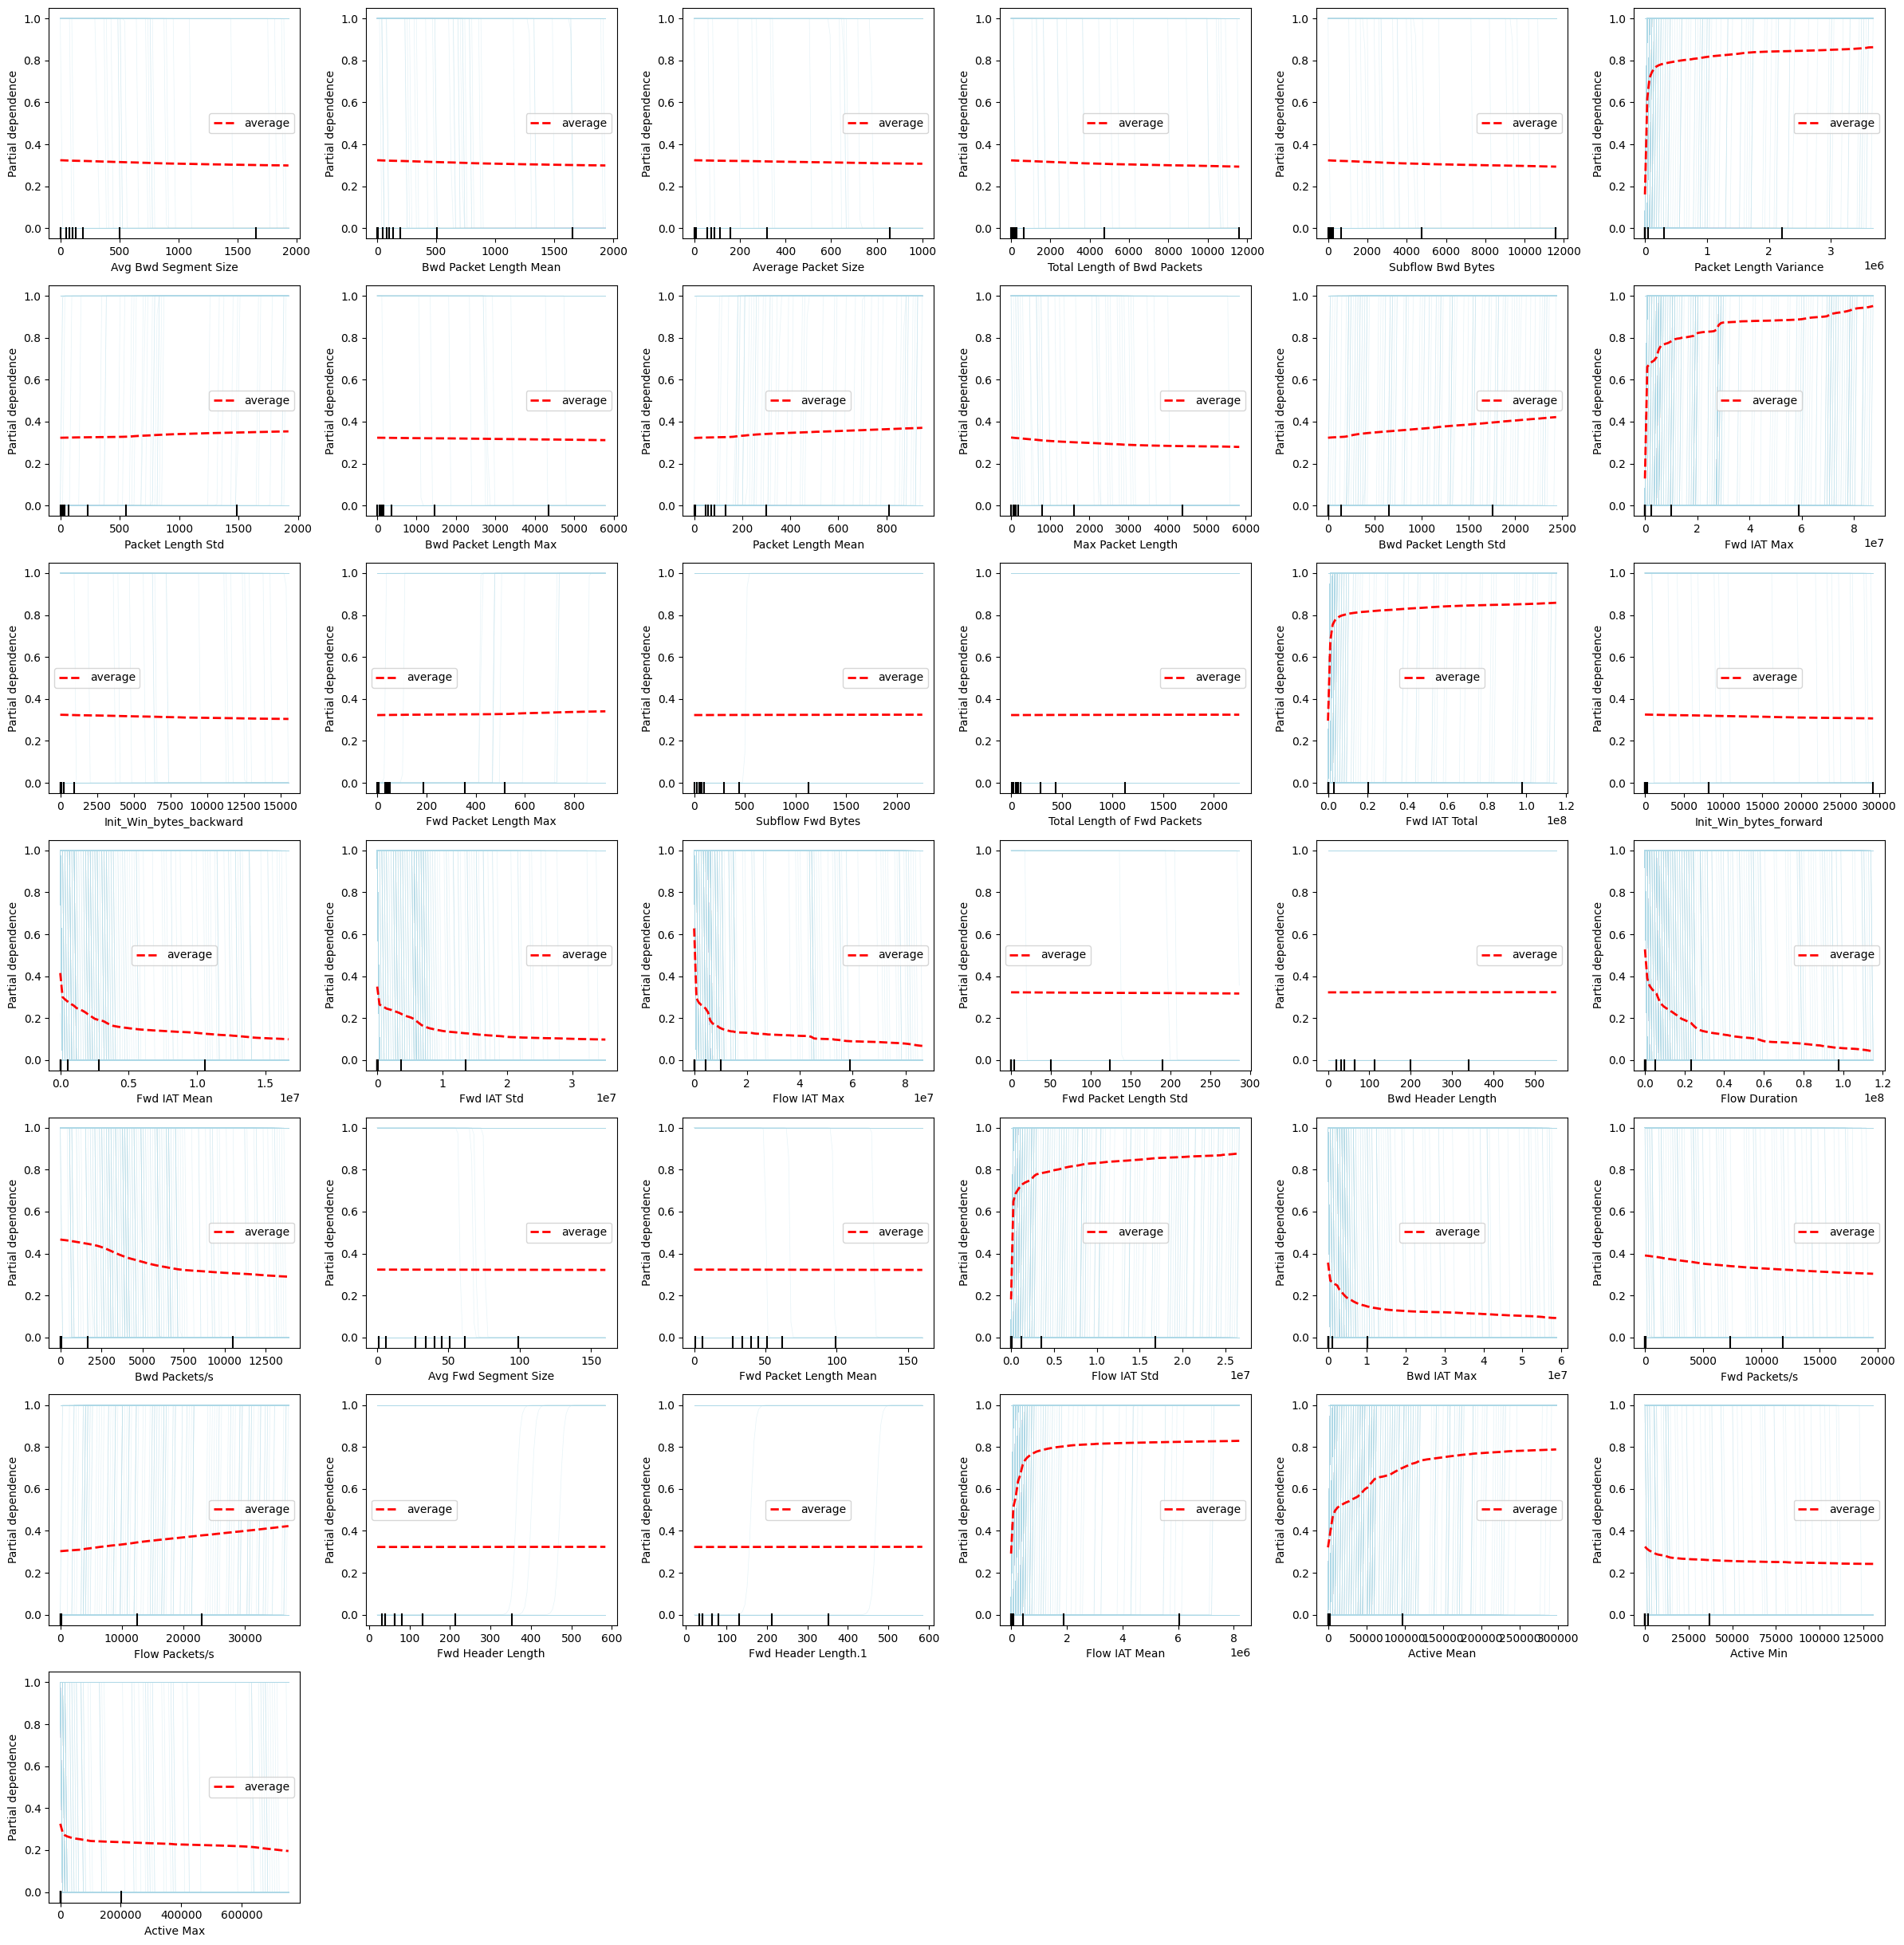

In [ ]:
# PDP series for fetch for XAI metrics

warnings.filterwarnings("ignore")
n_cols = 6
n_rows = (len(features) + n_cols - 1) // n_cols
fig, ax = plt.subplots(n_rows,n_cols,figsize=(24, 3.5 * n_rows))

ax = ax.flatten()

pdp_importance = {}

for i, feature in enumerate(tqdm(features, desc="Generating PDPs")):
  display = PartialDependenceDisplay.from_estimator(model,X_pdp,[feature],kind='both',target=1,grid_resolution=100,ax=ax[i],pd_line_kw={'color': 'red', 'linewidth': 2},ice_lines_kw={'color': 'lightblue', 'linewidth': 0.5, 'alpha': 0.3})
  avg_pred = display.pd_results[0]['average'][0]
  pdp_importance[feature] = np.std(avg_pred)

for i in range(len(features), len(ax)):
    ax[i].set_visible(False)

warnings.filterwarnings("ignore")

plt.tight_layout()
plt.show()

pdp_importance_series = pd.Series(pdp_importance).sort_values(ascending=False)

In [ ]:
features = X_pdp.columns.tolist()

In [ ]:
# Permutation Score and faithfullness
perm_result = permutation_importance(model, X_pdp, y_pdp, n_repeats=10, random_state=0)
perm_importance_series = pd.Series(perm_result.importances_mean, index=X_pdp.columns)
common_features = pdp_importance_series.index
faithfulness_corr, _ = pearsonr(pdp_importance_series[common_features],perm_importance_series[common_features])
print("PDP-based Faithfulness (correlation with permutation importance):", faithfulness_corr)

PDP-based Faithfulness (correlation with permutation importance): -0.817744333681955


In [ ]:
#sparsity
threshold = 0.01 * pdp_importance_series.max()
is_negligible = pdp_importance_series < threshold
sparsity = is_negligible.sum() / len(pdp_importance_series)
print("Sparsity:", sparsity)

Sparsity: 0.21621621621621623


In [ ]:
# Randomization

np.random.seed(0)
Y_shuffled = y_pdp.sample(frac=1, random_state=0).reset_index(drop=True)

random_model = clone(model)
random_model.fit(X_pdp, Y_shuffled)
pdp_importance_random = {}
for feature in tqdm(features, desc="Generating PDPs (random model)"):
    display = PartialDependenceDisplay.from_estimator(random_model, X_pdp, [feature], kind='average', target=1, grid_resolution=100)
    avg_pred = display.pd_results[0]['average'][0]
    pdp_importance_random[feature] = np.std(avg_pred)
    plt.close()
pdp_importance_random_series = pd.Series(pdp_importance_random)
x_trained = pdp_importance_series[common_features].values
x_random = pdp_importance_random_series[common_features].values
randomization_corr, p_val = pearsonr(x_trained, x_random)
print("Randomization test correlation (lower = better):", randomization_corr)

Generating PDPs (random model): 100%|██████████| 37/37 [20:22<00:00, 33.04s/it]

Randomization test correlation (lower = better): -0.03983961297248872


In [ ]:
# Sensitivity

import numpy as np

np.random.seed(0)
noise = 0.01
X_pdp_perturbed = X_pdp.copy()
for i in X_pdp_perturbed.columns:
    sigma = noise * X_pdp_perturbed[i].std()
    X_pdp_perturbed[i] += np.random.normal(0, sigma, size=len(X_pdp_perturbed))

pdp_importance_perturbed = {}
for feature in tqdm(features, desc="Generating PDPs (perturbed)"):
    display = PartialDependenceDisplay.from_estimator(model, X_pdp_perturbed, [feature], kind='average', target=1, grid_resolution=100)
    avg_pred = display.pd_results[0]['average'][0]
    pdp_importance_perturbed[feature] = np.std(avg_pred)
    plt.close()

pdp_importance_perturbed_series = pd.Series(pdp_importance_perturbed)

x = pdp_importance_series[common_features].values
x_prime = pdp_importance_perturbed_series[common_features].values

sensitivity = np.linalg.norm(x - x_prime) / np.linalg.norm(x)
print("Sensitivity (lower = more stable):", sensitivity)

Generating PDPs (perturbed): 100%|██████████| 37/37 [18:49<00:00, 30.53s/it]

Sensitivity (lower = more stable): 2.2373717473765424
